# 05 — Notebook verification demo
Compare a questioned signature with five quality-approved references using top-two-average cosine similarity. Run the cells in order.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from signature_verification.evaluation import load_model, verify_signatures
from signature_verification.preprocessing import preprocess_signature

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'artifacts/baseline/best.pt').exists(), 'best.pt not found'
assert (PROJECT_ROOT / 'artifacts/baseline/thresholds.json').exists(), 'thresholds.json not found'
metadata = pd.read_csv(PROJECT_ROOT / 'data/splits/cedar_metadata.csv')
threshold = json.loads((PROJECT_ROOT / 'artifacts/baseline/thresholds.json').read_text())['threshold']
model, preprocess_config, device = load_model(PROJECT_ROOT / 'artifacts/baseline/best.pt')
print(f'Device: {device} | Threshold: {threshold:.6f} | Samples: {len(metadata):,}')

d:\rishikeesh\Desktop\workspace\projects\signature_verification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | Threshold: 0.706854 | Samples: 2,640


In [2]:
def quality_approved(paths):
    approved = []
    for path in paths:
        _, quality, _ = preprocess_signature(path, preprocess_config)
        if quality.usable:
            approved.append(Path(path))
    return approved

def test_query(reference_paths, query_path, title='Questioned signature'):
    result = verify_signatures(model, reference_paths, query_path, threshold, preprocess_config, device)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    axes[0].imshow(Image.open(reference_paths[0]), cmap='gray')
    axes[0].set_title(f'Reference (1 of {len(reference_paths)})')
    axes[1].imshow(Image.open(query_path), cmap='gray')
    axes[1].set_title(title)
    for axis in axes: axis.axis('off')
    plt.show()
    print('Decision:', result['decision'])
    if 'score' in result:
        print(f"Aggregate score: {result['score']:.6f}")
        print(f"Threshold:       {result['threshold']:.6f}")
        print('Reference scores:', [round(score, 6) for score in result['reference_scores']])
    if result.get('quality_reasons'): print('Quality reasons:', result['quality_reasons'])
    return result

## Known genuine and skilled-forgery tests
Select a writer from the untouched test split with at least six usable genuine samples and one usable skilled forgery.

Test writer: CEDAR_02 | usable genuine: 24 | usable forgeries: 24


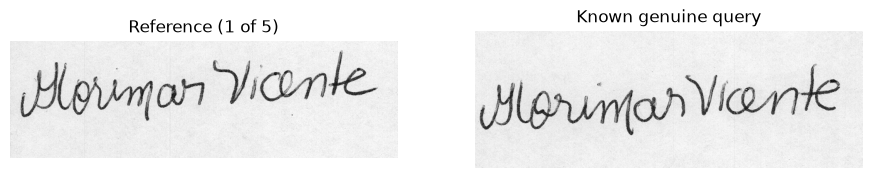

Decision: ACCEPT
Aggregate score: 0.980470
Threshold:       0.706854
Reference scores: [0.972242, 0.898892, 0.942013, 0.843807, 0.988698]


In [3]:
for writer in metadata.loc[metadata.split == 'test', 'writer_id'].unique():
    writer_genuine = metadata[(metadata.writer_id == writer) & (metadata.sample_type == 'GENUINE')]
    writer_forgery = metadata[(metadata.target_writer_id == writer) & (metadata.sample_type == 'FORGERY')]
    usable_genuine = quality_approved(writer_genuine.image_path)
    usable_forgeries = quality_approved(writer_forgery.image_path)
    if len(usable_genuine) >= 6 and usable_forgeries:
        break
else:
    raise RuntimeError('No test writer has enough quality-approved samples')

references = usable_genuine[:5]
print(f'Test writer: {writer} | usable genuine: {len(usable_genuine)} | usable forgeries: {len(usable_forgeries)}')
genuine_result = test_query(references, usable_genuine[5], 'Known genuine query')

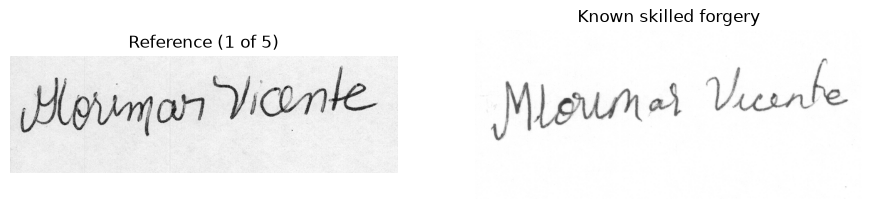

Decision: ACCEPT
Aggregate score: 0.808136
Threshold:       0.706854
Reference scores: [0.639205, 0.768873, 0.689466, 0.847399, 0.491537]


In [4]:
forgery_result = test_query(references, usable_forgeries[0], 'Known skilled forgery')

## Test the supplied `data/test` folders
The first three naturally ordered images in `data/test/001` are enrollment references. The remaining genuine images and every image in `data/test/001_forg` are questioned signatures.

In [5]:
import re

def sample_number(path):
    match = re.search(r'_(\d+)$', path.stem)
    return int(match.group(1)) if match else path.name

test_root = PROJECT_ROOT / 'data/test'
genuine_files = sorted((test_root / '001').glob('*.*'), key=sample_number)
forgery_files = sorted((test_root / '001_forg').glob('*.*'), key=sample_number)
references = genuine_files[:3]
genuine_queries = genuine_files[3:]
assert len(references) >= 3, 'At least three genuine reference images are required'
assert genuine_queries and forgery_files, 'Genuine and forgery queries are required'

rows = []
for expected, queries in [('GENUINE', genuine_queries), ('FORGERY', forgery_files)]:
    for query in queries:
        result = verify_signatures(model, references, query, threshold, preprocess_config, device)
        rows.append({
            'file': query.name, 'expected': expected,
            'decision': result['decision'], 'score': result.get('score'),
            'correct': (result['decision'] == 'ACCEPT') if expected == 'GENUINE' else (result['decision'] == 'REJECT'),
            'quality_reasons': ', '.join(result.get('quality_reasons', [])),
        })
results = pd.DataFrame(rows)
print('References:', [path.name for path in references])
print(f'Correct: {results.correct.sum()}/{len(results)} ({results.correct.mean():.1%})')
display(results.style.format({'score': '{:.6f}'}).background_gradient(subset=['score'], cmap='RdYlGn'))

References: ['1-001_01.jpg', '1-001_02.jpg', '1-001_03.jpg']
Correct: 7/17 (41.2%)


,file,expected,decision,score,correct,quality_reasons
0,1-001_04.jpg,GENUINE,ACCEPT,0.973595,True,
1,1-001_05.jpg,GENUINE,ACCEPT,0.951340,True,
2,1-001_06.jpg,GENUINE,ACCEPT,0.966740,True,
3,1-001_07.jpg,GENUINE,ACCEPT,0.974485,True,
4,1-001_08.jpg,GENUINE,ACCEPT,0.991009,True,
5,1-001_09.jpg,GENUINE,ACCEPT,0.997394,True,
6,1-001_010.jpg,GENUINE,ACCEPT,0.989364,True,
7,1-002_01.jpg,FORGERY,ACCEPT,0.997921,False,
8,1-002_02.jpg,FORGERY,ACCEPT,0.997434,False,
9,1-002_03.jpg,FORGERY,ACCEPT,0.997020,False,


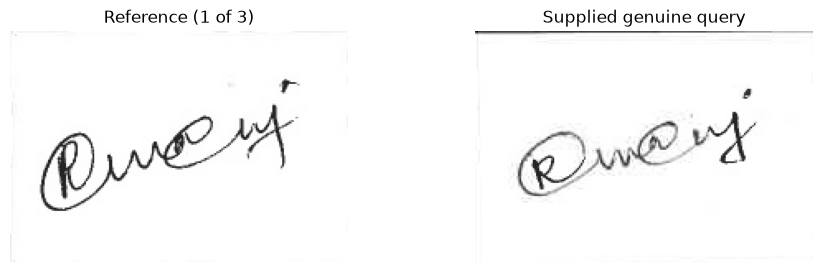

Decision: ACCEPT
Aggregate score: 0.973595
Threshold:       0.706854
Reference scores: [0.979037, 0.968153, 0.95896]


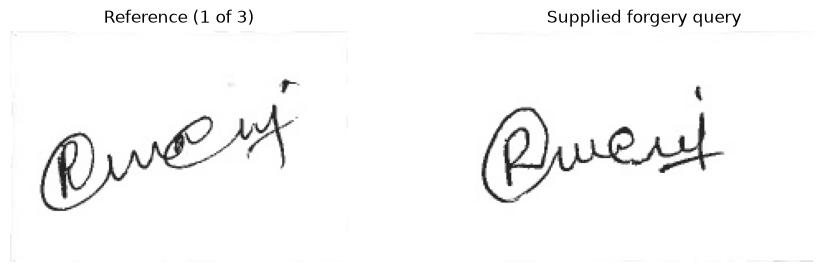

Decision: ACCEPT
Aggregate score: 0.997921
Threshold:       0.706854
Reference scores: [0.998327, 0.997516, 0.995775]


{'decision': 'ACCEPT',
 'score': 0.9979211986064911,
 'reference_scores': [0.9983265399932861,
  0.997515857219696,
  0.9957752227783203],
 'threshold': 0.7068539261817932,
 'quality_reasons': []}

In [6]:
# Visualize one supplied genuine query and one supplied forgery query.
test_query(references, genuine_queries[0], 'Supplied genuine query')
test_query(references, forgery_files[0], 'Supplied forgery query')